In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [2]:
data=pd.read_csv('train.csv')

In [3]:
data

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [6]:
data.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [7]:
data.isna().sum()/len(data)*100

date     0.0
store    0.0
item     0.0
sales    0.0
dtype: float64

In [8]:
dataframe = pd.concat([data.isna().sum().sort_values(ascending=False),data.isna().sum().sort_values(ascending=False)/len(data)*100],axis=1)

dataframe.columns = ["Missing values","% percentages"]
dataframe.style.background_gradient("Blues")

,Missing values,% percentages
date,0,0.000000
store,0,0.000000
item,0,0.000000
sales,0,0.000000


In [9]:
data[data.duplicated()].shape

(0, 4)

In [13]:
data['date'].unique().shape

(1826,)

In [14]:
data['date'].duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
912995     True
912996     True
912997     True
912998     True
912999     True
Name: date, Length: 913000, dtype: bool

In [16]:
data_c = data.copy()
enc = dict()
for i in data.columns:
    if data_c[i].dtype == 'object':
        enc[i] = LabelEncoder()
        data_c[i] = enc[i].fit_transform(data_c[i])
data_c


,date,store,item,sales
0,0,1,1,13
1,1,1,1,11
2,2,1,1,14
3,3,1,1,13
4,4,1,1,10
...,...,...,...,...
912995,1821,10,50,63
912996,1822,10,50,59
912997,1823,10,50,74
912998,1824,10,50,62


In [17]:
data_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  int32
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int32(1), int64(3)
memory usage: 24.4 MB


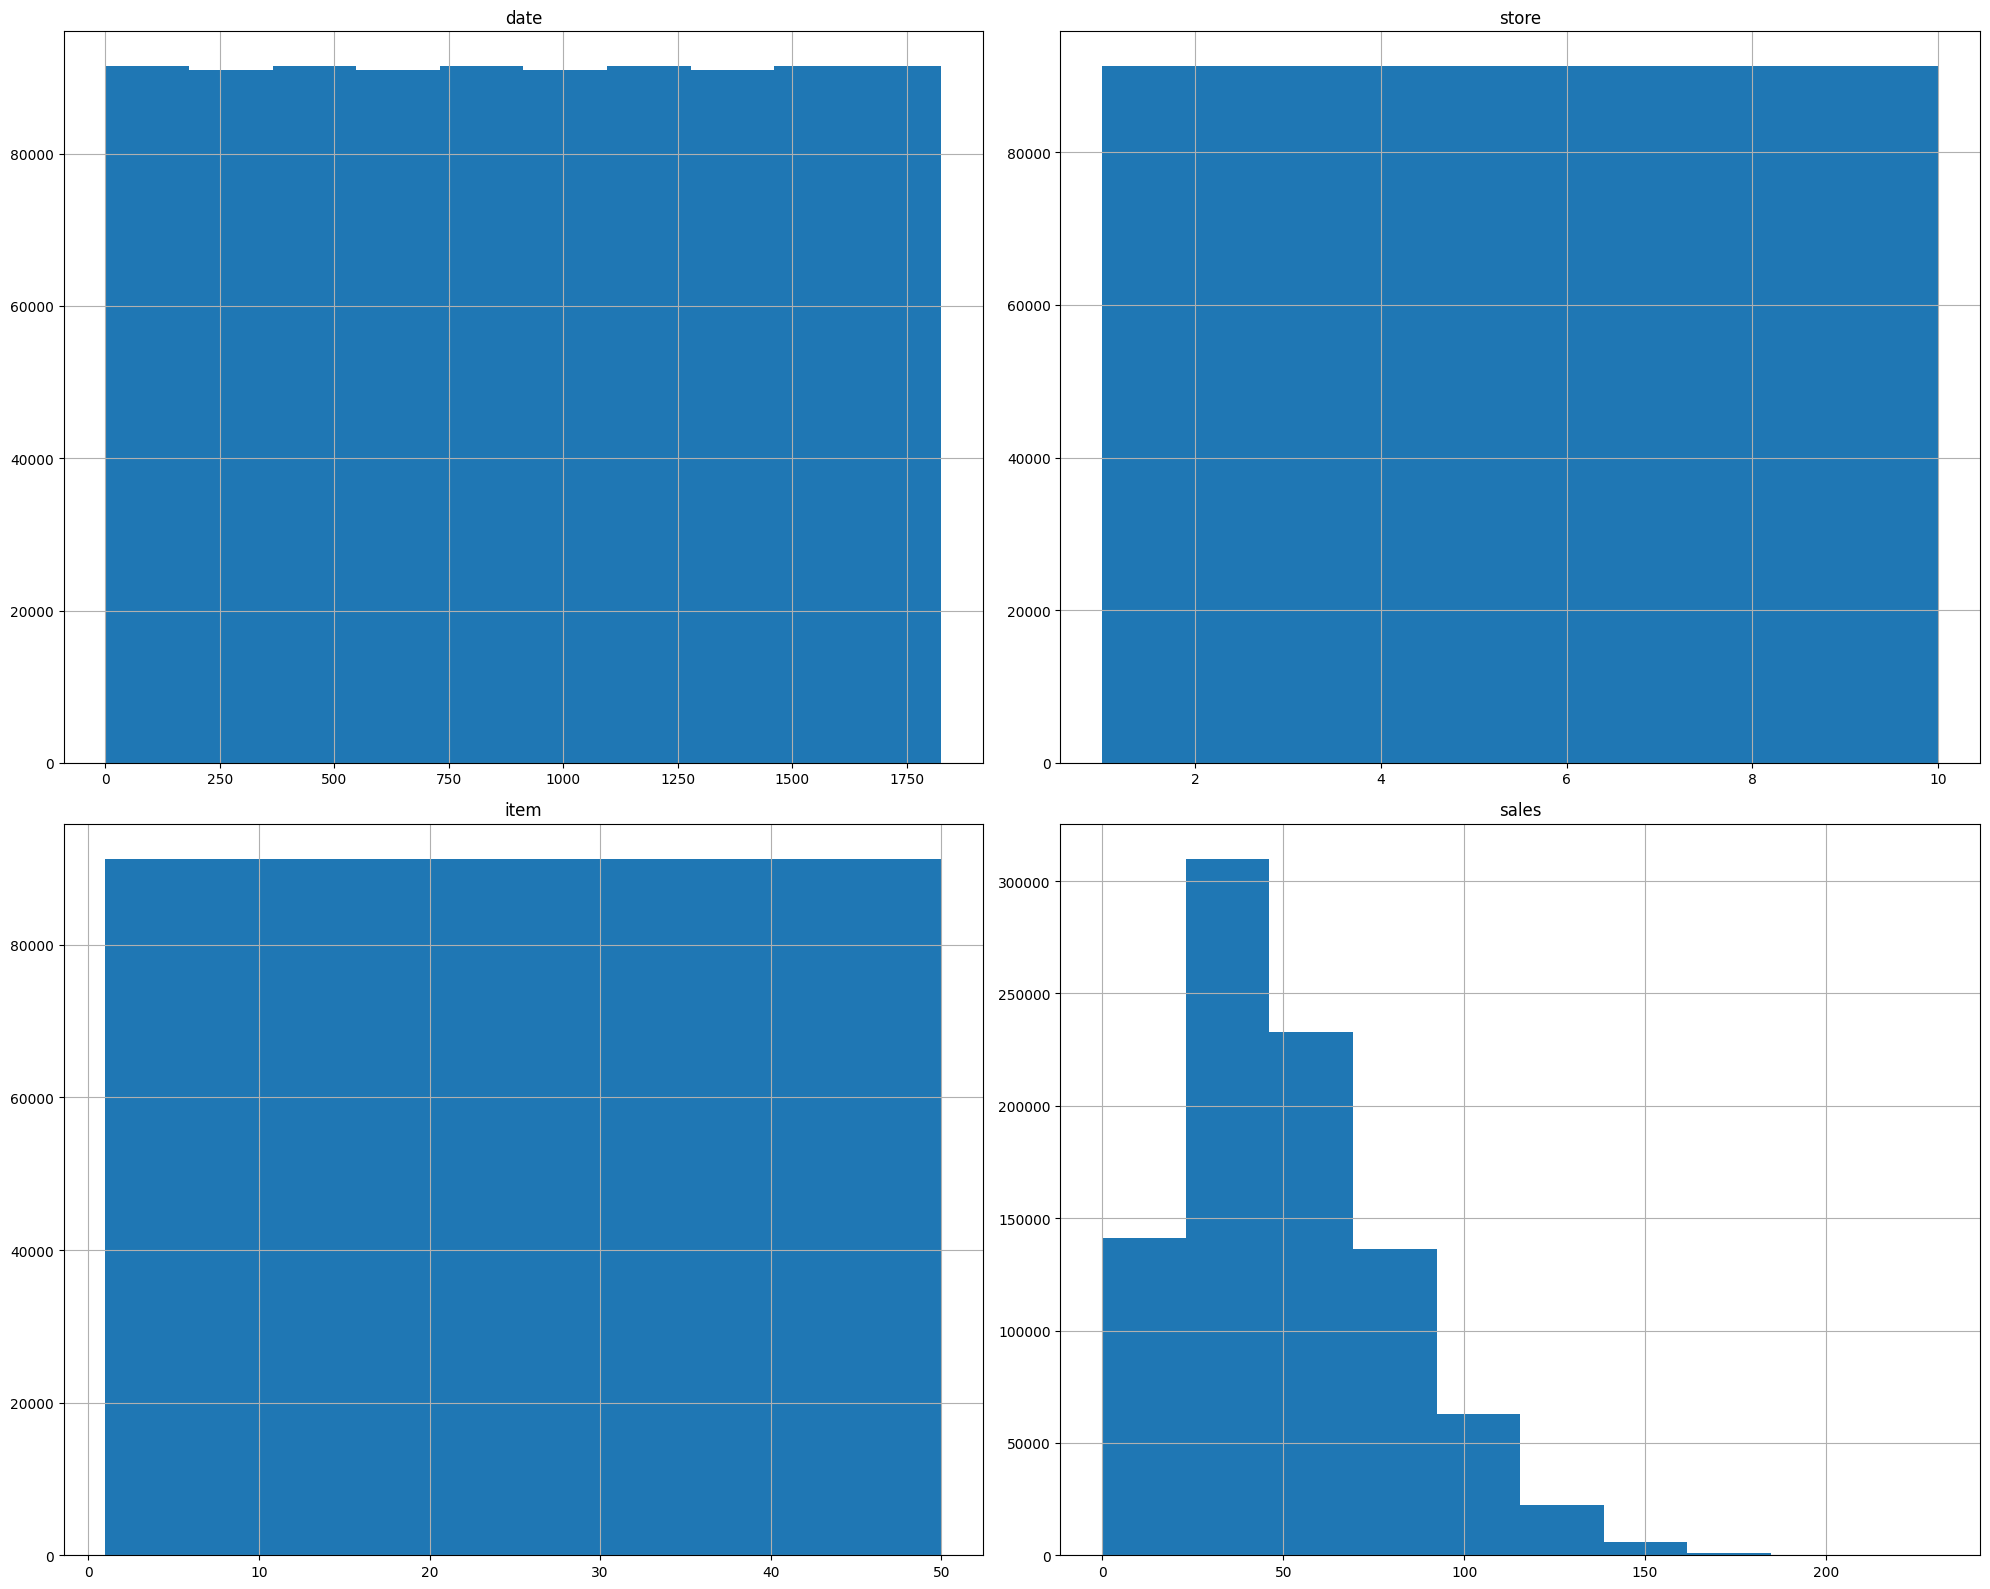

In [21]:
data_c.hist(figsize=(20,16))
plt.tight_layout()
plt.show()

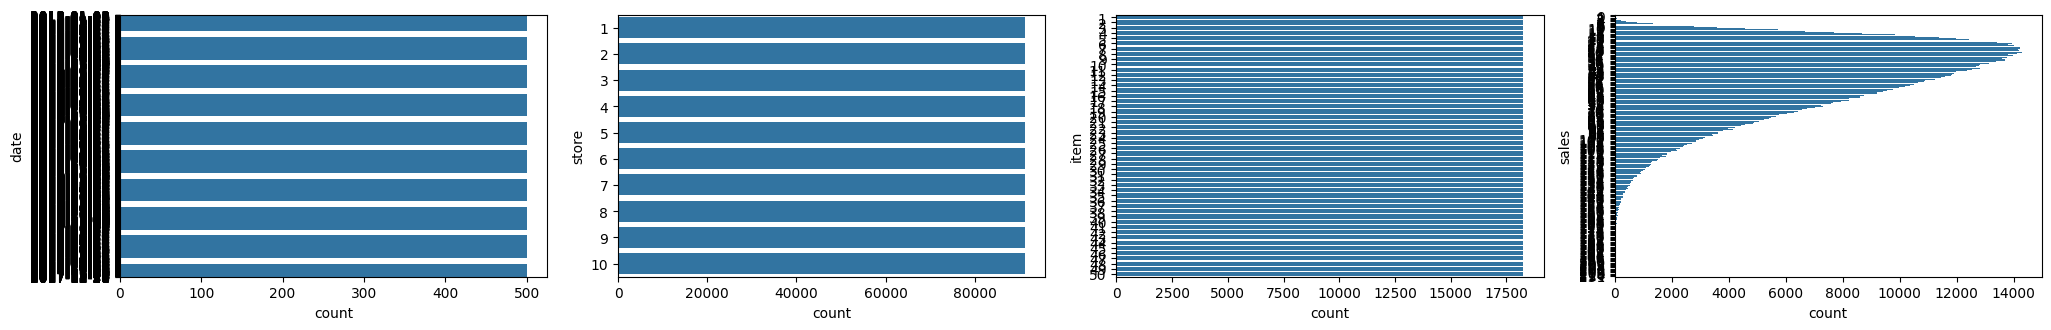

In [26]:
plt.figure(figsize=(200,160))
c = 1
for i in data_c.columns:
        plt.subplot(50,40,c)
        sns.countplot(data=data,y=i)
        c += 1
        if data_c[i].dtype == np.dtype("object"):
            plt.subplot(50,40,c)
            sns.countplot(data=data,y=i)
plt.tight_layout()
plt.show()

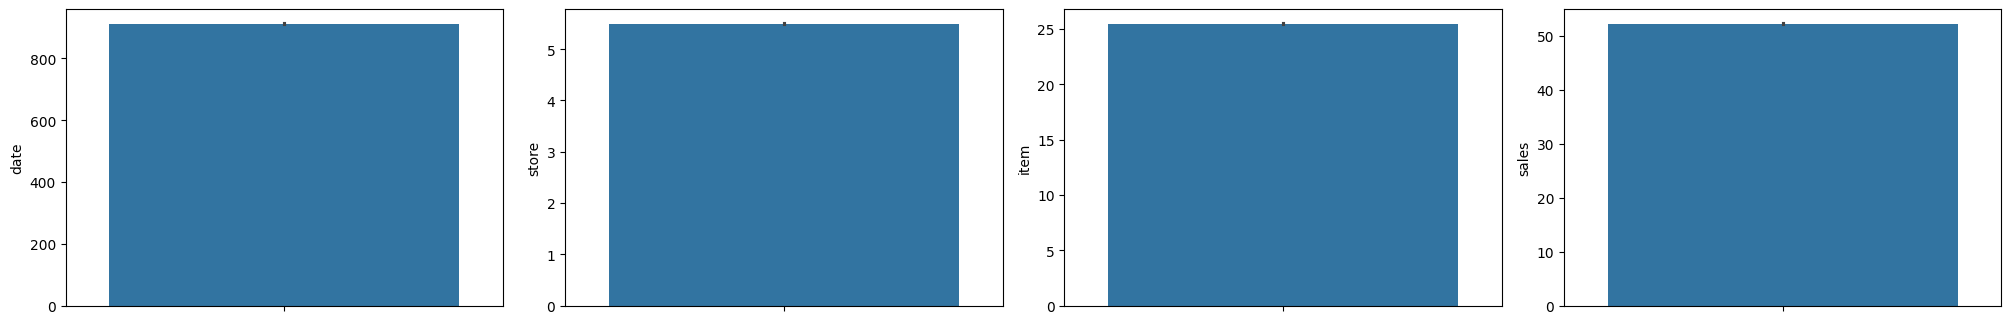

In [27]:
plt.figure(figsize=(200,160))
c = 1
for i in data_c.columns:
        plt.subplot(50,40,c)
        sns.barplot(data=data_c,y=i)
        c += 1
plt.tight_layout()
plt.show()